# Act 07 v2 (robusta) — Walk-forward, mesetas y evaluación única en test (NVDA)

Microestructura y Sistemas de Trading, ITESO. Este notebook solo importa, ejecuta y presenta:
la lógica vive en `src/` (`walk_forward.py`, `robust_evaluation.py`, `optimization.py`, `regimes.py`,
`plots.py`). El notebook de la v1 (`Act_07_regimes.ipynb`) no se modifica.

**Datos:** `data/NVDA_daily.csv` recortado al fin de test (`SPLITS["test"][1]` = 2025-09-14).
El walk-forward usa **solo train**; test se evalúa **una sola vez** al final (sección 8).
Validation **no se carga**.

| Periodo | Fechas | Uso |
|---|---|---|
| Train | 2021-09-15 a 2024-09-14 | walk-forward (ajuste y evaluación fuera de muestra) |
| Test | 2024-09-15 a 2025-09-14 | evaluación única |
| Validation | 2025-09-15 en adelante | no se carga |

In [2]:
import os, sys
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
os.chdir(ROOT)

import re
import subprocess
import sys
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

from src.analysis import win_rate_standard_error
from src.optimization import MIN_TRADES, PARAM_SPACE, THETA0, convergence_curve, optimize_all, theta_table
from src.plots import plot_convergence, plot_equity_curves, plot_plateau
from src.regimes import REGIME_NAMES, fit_regime_models, regime_labels
from src.robust_evaluation import (EDGE_FRACTION, drop_table, edge_params, robust_comparison_table,
                                   robust_strategy_runs, walk_forward_j)
from src.splits import SPLITS
from src.walk_forward import (BLOCKS, EXIT_PARAMS, FIT_START, MIN_TRADES_GLOBAL, MIN_TRADES_REGIME,
                              N_STARTUP_TRIALS, N_TRIALS, PLATEAU_FRACTION, blocks_table,
                              block_centroids, operating_thetas, run_walk_forward, summary_table,
                              top_trials)

pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
pd.set_option("display.max_columns", 30)
plt.rcParams.update({"figure.dpi": 110, "font.size": 10})

TEST_END = SPLITS["test"][1]
split_date = pd.Timestamp(SPLITS["test"][0])

df = pd.read_csv("data/NVDA_daily.csv", index_col="Date", parse_dates=True).loc[:TEST_END]
assert df.index.max() <= pd.Timestamp(TEST_END)  # validation no se carga
print(f"Barras: {len(df)} ({df.index[0].date()} a {df.index[-1].date()})")

Barras: 1003 (2021-09-15 a 2025-09-12)


## 1. Motivo: overfitting de la v1

La v1 optimizó con Optuna los 6 parámetros de θ = (roc_window, cmf_window, adx_threshold, sl_mult,
rr, max_holding) para cada régimen HMM (**18 parámetros**) más θ\* único, con J = Calmar en **todo
train** (un solo periodo de evaluación). Se re-ejecuta aquí (es determinista, semilla 42) para tener
sus θ y compararlos en test:

In [3]:
models = fit_regime_models(df)   # scaler, p90 y HMM con TODO train (decisión 7 del pre-registro)
start = time.time()
opt_v1 = optimize_all(df, models)
print(f"Optimización v1 (4 estudios x 500 trials, solo train): {time.time() - start:.0f} s")
thetas_v1 = theta_table(df, models, opt_v1)
thetas_v1

c:\Users\Isabela\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] El sistema no puede encontrar el archivo especificado
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\Isabela\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\Isabela\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Isabela\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Users\Isabela\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, t

Optimización v1 (4 estudios x 500 trials, solo train): 29 s


,roc_window,cmf_window,adx_threshold,sl_mult,rr,max_holding,tp_mult,J_train,trades_train,operates
θ0,10,20,25.0000,2.0000,1.5000,10,3.0000,1.6830,62,True
θ*,20,16,34.2259,2.3986,2.9731,19,7.1312,4.9021,21,True
θ*_crisis,9,12,26.2993,1.9099,2.1100,7,4.0299,2.1301,22,True
θ*_trend,21,19,34.3069,2.8848,1.6941,15,4.8871,3.5799,12,True
θ*_mean_reversion,26,21,17.5630,1.2284,2.0874,10,2.5641,1.8307,14,True


In [4]:
adx_high = PARAM_SPACE["adx_threshold"][2]
display(Markdown(f"""
Síntomas en v1 (solo train, ya reportados en `Act_07_regimes.ipynb`):

- **θ\\* pegado al mínimo de trades:** {thetas_v1.loc["θ*", "trades_train"]} trades en train con
  MIN_TRADES = {MIN_TRADES}.
- **ADX en el borde:** θ\\* usa adx_threshold = {opt_v1.theta_star["adx_threshold"]:.1f} y θ\\*_trend
  {opt_v1.regime_thetas["trend"]["adx_threshold"]:.1f}, contra un máximo de {adx_high:.0f}.
- **Caída train → test** del Calmar (se recalcula en la sección 8 con la misma corrida).

Respuesta (lo visto en clase): **menos parámetros** (la señal queda fija), **walk-forward** (J fuera de
muestra) y **mesetas en lugar de picos** (θ final = mediana del top {PLATEAU_FRACTION:.0%}).
"""))


Síntomas en v1 (solo train, ya reportados en `Act_07_regimes.ipynb`):

- **θ\* pegado al mínimo de trades:** 21 trades en train con
  MIN_TRADES = 20.
- **ADX en el borde:** θ\* usa adx_threshold = 34.2 y θ\*_trend
  34.3, contra un máximo de 35.
- **Caída train → test** del Calmar (se recalcula en la sección 8 con la misma corrida).

Respuesta (lo visto en clase): **menos parámetros** (la señal queda fija), **walk-forward** (J fuera de
muestra) y **mesetas en lugar de picos** (θ final = mediana del top 10%).


## 2. Pre-registro

El diseño completo se fijó en [`ACT07_ROBUST.md`](ACT07_ROBUST.md) **antes** de escribir código. Las
aclaraciones posteriores (decisión 9: redondeo half-up; decisiones 10–12: cómo se calculan los
criterios) se commitearon **antes** de evaluar test. Historial del archivo:

In [5]:
log = subprocess.run(["git", "log", "--format=%h|%ad|%s", "--date=format:%Y-%m-%d %H:%M", "--",
                      "docs/ACT07_ROBUST.md", "ACT07_ROBUST.md", "src/walk_forward.py"],
                     capture_output=True, text=True).stdout.strip().splitlines()
pd.DataFrame([line.split("|", 2) for line in log], columns=["commit", "fecha", "mensaje"]).iloc[::-1] \
    .reset_index(drop=True)

,commit,fecha,mensaje
0,e7bc860,2026-10-02 13:35,Act 07 v2: pre-register robust walk-forward op...
1,c35e7f2,2026-10-02 13:44,Act 07 v2: clarify max_holding half-up roundin...
2,dda132d,2026-10-02 13:53,Act 07 v2: walk-forward optimization with per-...
3,d93a734,2026-10-02 14:04,Act 07 v2: clarify criteria (a) and (b) before...
4,92f3f9a,2026-10-02 14:13,"Act 07 v2: single test evaluation, pre-registe..."


## 3. Diseño walk-forward

- **Señal fija del SPEC:** ROC(10) > 0, CMF(20) > 0, ADX(14) > 25 (simétrico en short). No se optimiza.
- **Solo se optimiza la salida** (tp = sl · rr), con los rangos de abajo:
  - θ\* robusto: 3 parámetros, mínimo de trades fuera de muestra = 20.
  - θ\*_j robusto: un estudio por régimen HMM (3 × 3 = 9 parámetros, vs 18 en v1), mínimo 10 trades;
    solo hay entradas cuya barra de señal tiene etiqueta filtrada = j.
  - Regla a priori: si el mejor J_j ≤ 0 o ningún trial llega a 10 trades, en j **no se opera**.
- **Ventana creciente dentro de train**, 3 bloques. En cada bloque el scaler, el umbral p90 y el HMM
  (cascada de 10 semillas) se ajustan **una vez** con datos ≤ fin del ajuste y se reutilizan en todos
  los trials.
- **J = Calmar** de la equity fuera de muestra: los 3 tramos de evaluación encadenados **por
  rendimientos** (cada tramo arranca plano con el capital inicial).
- **Optuna:** 200 trials por estudio = 100 random + 100 TPE, semilla 42.
- **θ final = mediana por parámetro del top 10%** (20 trials); max_holding se redondea half-up.

In [6]:
display(pd.DataFrame([{"bloque": i, "ajuste": f"{FIT_START} → {b.fit_end}",
                       "evaluación (OOS)": f"{b.eval_start} → {b.eval_end}"}
                      for i, b in enumerate(BLOCKS, 1)]).set_index("bloque"))
pd.DataFrame({p: {"tipo": PARAM_SPACE[p][0], "mínimo": PARAM_SPACE[p][1], "máximo": PARAM_SPACE[p][2],
                  "θ0": THETA0[p]} for p in EXIT_PARAMS}).T

,ajuste,evaluación (OOS)
bloque,,
1,2021-09-15 → 2023-03-14,2023-03-15 → 2023-09-14
2,2021-09-15 → 2023-09-14,2023-09-15 → 2024-03-14
3,2021-09-15 → 2024-03-14,2024-03-15 → 2024-09-14


,tipo,mínimo,máximo,θ0
sl_mult,float,1.0000,3.0000,2.0000
rr,float,1.0000,3.0000,1.5000
max_holding,int,5,20,10


## 4. Tests anti look-ahead (`tests/test_walk_forward.py`)

| Test | Qué prueba |
|---|---|
| `test_block_models_ignore_data_after_fit_end` | Los modelos de cada bloque (scaler, p90, HMM, nombres, cascada) son idénticos con el df completo, con `df.loc[:fin_de_ajuste]` y con todo lo posterior corrompido con ruido. |
| `test_eval_block_ignores_data_after_eval_end` | Para cada bloque y estudio (global y 3 regímenes), etiquetas, equity y trades del tramo de evaluación son idénticos si se borra o corrompe todo lo posterior al tramo. |
| `test_combined_ignores_data_after_eval_end` | Lo mismo para la estrategia combinada por régimen. |
| `test_sliced_backtest_matches_masked_full_backtest` | Correr el backtest solo en el tramo == correrlo hasta el fin del tramo permitiendo entradas solo con barra de señal en el tramo (decisión 4). |
| `test_chain_equity_*` | La equity OOS encadena rendimientos (caso a mano: [100, 110] y [100, 90] → [100, 110, 110, 99]). |
| `test_plateau_*` | Mediana del top 10% y redondeo half-up (caso a mano: 12.5 → 13). |
| resto | Regla a priori, entradas solo en su régimen, combinada == estudio de un régimen. |

In [7]:
run = subprocess.run([sys.executable, "-m", "pytest", "tests/test_walk_forward.py", "-v", "--color=no",
                      "-p", "no:warnings"], capture_output=True, text=True)
results = pd.DataFrame(re.findall(r"::(test_\w+)(?:\[[^\]]*\])? (PASSED|FAILED)", run.stdout),
                       columns=["test", "resultado"])
display(pd.crosstab(results["test"], results["resultado"]))
print(run.stdout.strip().splitlines()[-1])

resultado,PASSED
test,
test_block_models_ignore_data_after_fit_end,3
test_chain_equity_compounds_returns_hand_case,1
test_chain_equity_first_bar_against_initial_cash,1
test_combined_entries_use_their_regime_theta,3
test_combined_ignores_data_after_eval_end,3
test_combined_with_one_regime_equals_regime_run,2
test_eval_block_ignores_data_after_eval_end,12
test_eval_window_is_inside_block,1
test_operates_rule,4


============================= 46 passed in 57.84s =============================


## 5. Walk-forward: HMM y centroides por bloque

Centroides en unidades originales (volatility anualizada, trend_r2, autocorr_1) y número de barras de
cada régimen en el tramo de evaluación del bloque.

In [8]:
start = time.time()
wf = run_walk_forward(df)   # 3 bloques x 4 estudios x 200 trials, SOLO train
print(f"Walk-forward: {time.time() - start:.0f} s")
blocks = blocks_table(wf)
blocks

c:\Users\Isabela\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\Isabela\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\Isabela\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\Isabela\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak o

Walk-forward: 26 s


c:\Users\Isabela\Documents\Iteso\9no Semestre\Trading\trading_2026-1\lab_02\src\walk_forward.py:176: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  trades = pd.concat([r.trades for r in runs], ignore_index=True)
c:\Users\Isabela\Documents\Iteso\9no Semestre\Trading\trading_2026-1\lab_02\src\walk_forward.py:176: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  trades = pd.concat([r.trades for r in runs], ignore_index=True)
c:\Users\Isabela\Documents\Iteso\9no Semestre\Trading\trading_2026-1\lab_02\sr

,bloque 1,bloque 2,bloque 3
fit,2021-09-15..2023-03-14,2021-09-15..2023-09-14,2021-09-15..2024-03-14
eval,2023-03-15..2023-09-14,2023-09-15..2024-03-14,2024-03-15..2024-09-14
hmm_choice,full,full,full
vol_p90,0.7000,0.6897,0.6833
crisis volatility,0.7022,0.6224,0.6156
crisis trend_r2,0.5695,0.6211,0.2972
crisis autocorr_1,-0.1391,-0.1342,0.0150
crisis eval_bars,0,106,73
trend volatility,0.5946,0.5554,0.5765
trend trend_r2,0.5732,0.8119,0.7905


In [9]:
cent = [block_centroids(m) for m in wf.models]
eval_bars = {name: [int(blocks.loc[f"{name} eval_bars", c]) for c in blocks.columns] for name in REGIME_NAMES}
fmt = lambda xs, f: ", ".join(format(x, f) for x in xs)
display(Markdown(f"""
- Cascada HMM elegida por bloque: {", ".join(m.hmm_choice for m in wf.models)}.
- **Los nombres no son estables entre bloques.** "crisis" tiene trend_r2 =
  {fmt([c.loc["crisis", "trend_r2"] for c in cent], ".2f")} y volatilidad =
  {fmt([c.loc["crisis", "volatility"] for c in cent], ".2f")} en los bloques 1–3; la volatilidad de
  "mean_reversion" pasa de {cent[0].loc["mean_reversion", "volatility"]:.2f} a
  {cent[2].loc["mean_reversion", "volatility"]:.2f}. El nombre sale de una regla de orden sobre los
  centroides, así que el mismo nombre puede designar estados distintos en cada bloque.
- Barras por régimen en los tramos de evaluación: crisis {fmt(eval_bars["crisis"], "d")},
  trend {fmt(eval_bars["trend"], "d")}, mean_reversion {fmt(eval_bars["mean_reversion"], "d")}.
"""))


- Cascada HMM elegida por bloque: full, full, full.
- **Los nombres no son estables entre bloques.** "crisis" tiene trend_r2 =
  0.57, 0.62, 0.30 y volatilidad =
  0.70, 0.62, 0.62 en los bloques 1–3; la volatilidad de
  "mean_reversion" pasa de 0.62 a
  0.37. El nombre sale de una regla de orden sobre los
  centroides, así que el mismo nombre puede designar estados distintos en cada bloque.
- Barras por régimen en los tramos de evaluación: crisis 0, 106, 73,
  trend 127, 18, 53, mean_reversion 0, 1, 0.


## 6. Estudios: convergencia y meseta

Convergencia del mejor J walk-forward acumulado (los −∞ no se dibujan):

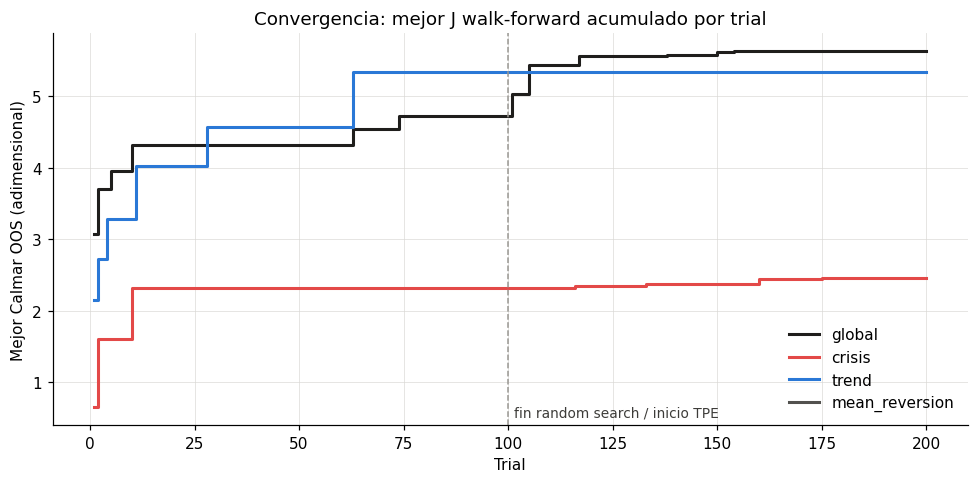

c:\Users\Isabela\Documents\Iteso\9no Semestre\Trading\trading_2026-1\lab_02\src\walk_forward.py:176: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  trades = pd.concat([r.trades for r in runs], ignore_index=True)


,global,crisis,trend,mean_reversion
min_trades,20,10,10,10
best_J,5.6321,2.4629,5.3389,-inf
n_finite,195,175,200,0
n_top,20,20,20,0
operates,True,True,True,False
best sl_mult,2.3152,2.0186,2.4296,1.7491
best rr,2.0760,2.5227,2.2919,2.9014
best max_holding,13,5,13,16
plateau_J,5.6390,2.4375,5.2723,NaN
plateau_trades,24,14,16,NaN


In [10]:
fig, ax = plt.subplots(figsize=(9, 4.5))
plot_convergence(ax, {name: convergence_curve(study) for name, study in wf.studies.items()},
                 n_startup=N_STARTUP_TRIALS,
                 title="Convergencia: mejor J walk-forward acumulado por trial",
                 ylabel="Mejor Calmar OOS (adimensional)")
plt.tight_layout()
plt.show()
summary = summary_table(wf)
summary

**Meseta.** Cada panel: J walk-forward de todos los trials con J finito (gris), el top 10% (color) y el
θ final = mediana del top (línea punteada). Una meseta se ve como un top agrupado sin un pico aislado.
Solo se grafican los estudios que operan.

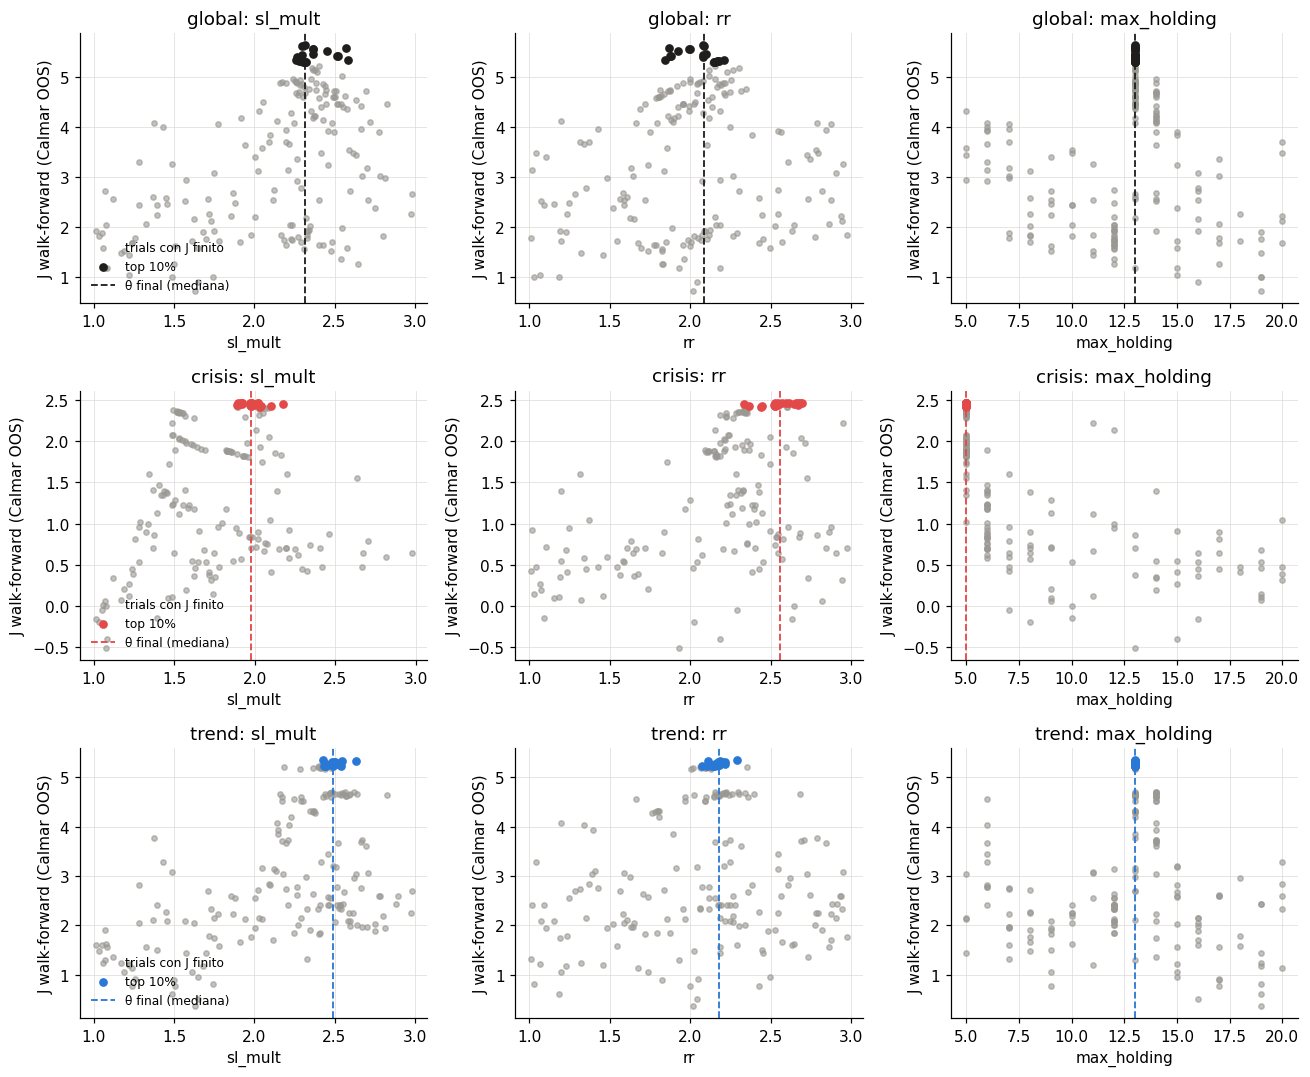

In [11]:
operating = [name for name in wf.studies if wf.operates[name]]
fig, axes = plt.subplots(len(operating), len(EXIT_PARAMS), figsize=(12, 3.3 * len(operating)), squeeze=False)
for row, name in zip(axes, operating):
    plot_plateau(row, wf.studies[name], top_trials(wf.studies[name]), wf.thetas[name], name)
plt.tight_layout()
plt.show()

## 7. θ finales

In [12]:
final = pd.DataFrame({name: {**{p: (wf.thetas[name] or {}).get(p, np.nan) for p in EXIT_PARAMS},
                             "J walk-forward": summary.loc["plateau_J", name],
                             "trades OOS": summary.loc["plateau_trades", name],
                             "trials finitos": summary.loc["n_finite", name],
                             "opera": wf.operates[name]}
                      for name in wf.studies}).T
final.index = [f"v2 θ*_{n}" if n != "global" else "v2 θ* robusto" for n in final.index]
v1_rows = thetas_v1.loc[["θ*", "θ*_crisis", "θ*_trend", "θ*_mean_reversion"], EXIT_PARAMS]
v1_rows.index = [f"v1 {i}" for i in v1_rows.index]
pd.concat([final, v1_rows])

,sl_mult,rr,max_holding,J walk-forward,trades OOS,trials finitos,opera
v2 θ* robusto,2.3163,2.0824,13,5.6390,24,195,True
v2 θ*_crisis,1.9739,2.5559,5,2.4375,14,175,True
v2 θ*_trend,2.4933,2.1754,13,5.2723,16,200,True
v2 θ*_mean_reversion,NaN,NaN,NaN,NaN,NaN,0,False
v1 θ*,2.3986,2.9731,19,NaN,NaN,NaN,NaN
v1 θ*_crisis,1.9099,2.1100,7,NaN,NaN,NaN,NaN
v1 θ*_trend,2.8848,1.6941,15,NaN,NaN,NaN,NaN
v1 θ*_mean_reversion,1.2284,2.0874,10,NaN,NaN,NaN,NaN


In [13]:
s = summary
display(Markdown(f"""
- **mean_reversion apagado:** {s.loc["n_finite", "mean_reversion"]} de {N_TRIALS} trials con J finito.
  Con {sum(eval_bars["mean_reversion"])} barras etiquetadas mean_reversion en los 3 tramos de evaluación,
  ningún θ puede llegar a {MIN_TRADES_REGIME} trades: se apaga por falta de datos, no por mal desempeño.
- **θ\\* robusto:** {int(s.loc["plateau_trades", "global"])} trades fuera de muestra con mínimo
  {MIN_TRADES_GLOBAL}.
"""))


- **mean_reversion apagado:** 0 de 200 trials con J finito.
  Con 1 barras etiquetadas mean_reversion en los 3 tramos de evaluación,
  ningún θ puede llegar a 10 trades: se apaga por falta de datos, no por mal desempeño.
- **θ\* robusto:** 24 trades fuera de muestra con mínimo
  20.


## 8. Evaluación única en test

Todo lo anterior quedó congelado (commits de la sección 2). Las 6 estrategias corren una sola vez sobre
train + test continuos, con los modelos de régimen ajustados con **todo train** (decisión 7); las
métricas de cada periodo salen de `summarize` (rebasa la equity al inicio del periodo, como en v1).
v2 θ\*_régimen robusto opera en crisis y trend con su θ de la meseta; mean_reversion apagado.

In [14]:
runs = robust_strategy_runs(df, models, opt_v1, wf)
table = robust_comparison_table(runs)
table

,buy & hold train,buy & hold test,θ0 train,θ0 test,v1 θ* train,v1 θ* test,v1 θ*_régimen train,v1 θ*_régimen test,v2 θ* robusto train,v2 θ* robusto test,v2 θ*_régimen robusto train,v2 θ*_régimen robusto test
equity_final,"533,024.8874","152,267.4842","127,922.5287","99,678.1842","130,488.5453","103,452.3141","136,304.1456","100,823.0538","132,044.0902","102,087.9328","126,922.1201","98,200.6803"
total_return,4.3302,0.5227,0.2792,-0.0032,0.3049,0.0345,0.3630,0.0082,0.3204,0.0209,0.2692,-0.0180
cagr,0.7507,0.5330,0.0859,-0.0033,0.0931,0.0351,0.1092,0.0084,0.0975,0.0212,0.0831,-0.0183
sharpe,1.2680,1.1075,1.6670,-0.0875,1.7293,1.2423,2.1515,0.2666,1.6484,0.6440,1.6665,-0.6517
sortino,2.0242,1.5979,3.1899,-0.1159,3.6931,1.9466,4.4127,0.3622,3.2052,0.8762,3.2436,-0.7867
max_drawdown,-0.6635,-0.3689,-0.0510,-0.0328,-0.0190,-0.0235,-0.0158,-0.0302,-0.0555,-0.0271,-0.0240,-0.0281
calmar,1.1314,1.4451,1.6830,-0.0998,4.9021,1.4916,6.9049,0.2771,1.7559,0.7822,3.4598,-0.6512
n_trades,0.0000,0.0000,62.0000,12.0000,21.0000,3.0000,47.0000,14.0000,47.0000,10.0000,51.0000,11.0000
trades_per_year,0.0000,0.0000,20.7490,12.1935,7.0279,3.0484,15.7291,14.2258,15.7291,10.1613,17.0677,11.1774
avg_pnl,NaN,NaN,450.3634,-34.3062,"1,451.8355","1,368.9462",772.4286,80.1326,681.7892,275.6992,527.8847,-207.6122


`p_star`, `p_star_cost` y `k_mean` suponen un solo SL/TP y no aplican a las estrategias por régimen (NaN).

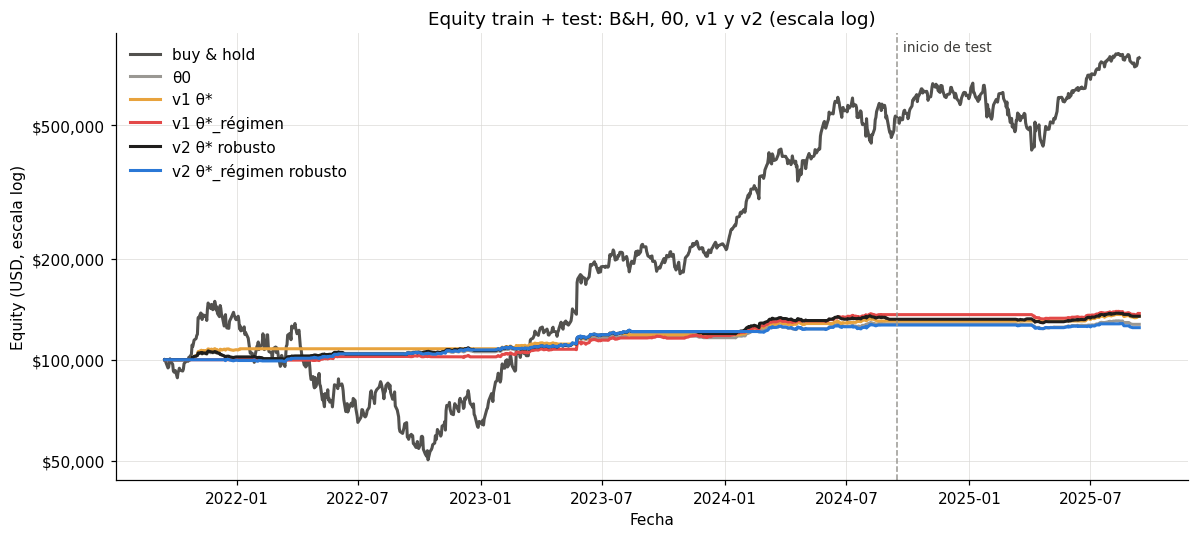

In [15]:
fig, ax = plt.subplots(figsize=(11, 5))
plot_equity_curves(ax, {name: equity["equity"] for name, (equity, _, _) in runs.items()}, split_date,
                   title="Equity train + test: B&H, θ0, v1 y v2 (escala log)")
plt.tight_layout()
plt.show()

## 9. Criterios pre-registrados

**Criterio (a)** (sección 8 y aclaraciones 10–11 del pre-registro): v2 se considera más robusta si
cae menos que v1, en caída **absoluta** (J_ref − J_test) **y** **relativa** ((J_ref − J_test) / J_ref).
J_ref es el Calmar en train para v1 y el J walk-forward para v2 (en θ\*_régimen, el de la estrategia
combinada fuera de muestra); J_test es el Calmar en test.

In [16]:
wf_j = walk_forward_j(wf)
crit_a = drop_table(table, wf_j)
crit_a

,v1 J_ref,v1 J_test,v1 caída abs,v1 caída rel,v2 J_ref,v2 J_test,v2 caída abs,v2 caída rel,abs cumple,rel cumple,cumple
θ*,4.9021,1.4916,3.4105,0.6957,5.6390,0.7822,4.8568,0.8613,False,False,False
θ*_régimen,6.9049,0.2771,6.6278,0.9599,6.4198,-0.6512,7.0710,1.1014,False,False,False


**Criterio (b)** (aclaración 12): ningún parámetro final a una distancia ≤ 10% del ancho del rango de
un límite. Solo los estudios que operan.

In [17]:
crit_b = edge_params({"v2 θ* robusto": wf.thetas["global"],
                      **{f"v2 θ*_{n}": t for n, t in operating_thetas(wf).items()}})
crit_b

valor  límite cercano  distancia / ancho  en_borde
estudio       parámetro                                                       
v2 θ* robusto sl_mult      2.3163          3.0000             0.3419     False
              rr           2.0824          3.0000             0.4588     False
              max_holding 13.0000         20.0000             0.4667     False
v2 θ*_crisis  sl_mult      1.9739          1.0000             0.4869     False
              rr           2.5559          3.0000             0.2220     False
              max_holding  5.0000          5.0000             0.0000      True
v2 θ*_trend   sl_mult      2.4933          3.0000             0.2534     False
              rr           2.1754          3.0000             0.4123     False
              max_holding 13.0000         20.0000             0.4667     False

In [18]:
verdict = lambda ok: "**se cumple**" if ok else "**no se cumple**"
lines = []
for row in crit_a.index:
    a = crit_a.loc[row]
    lines.append(
        f"- {row}: v1 {a['v1 J_ref']:.2f} → {a['v1 J_test']:.2f} (caída {a['v1 caída abs']:.2f}, "
        f"{a['v1 caída rel']:.0%}); v2 {a['v2 J_ref']:.2f} → {a['v2 J_test']:.2f} (caída "
        f"{a['v2 caída abs']:.2f}, {a['v2 caída rel']:.0%}). Absoluta: {'sí' if a['abs cumple'] else 'no'}; "
        f"relativa: {'sí' if a['rel cumple'] else 'no'} → {verdict(a['cumple'])}.")
edges = crit_b[crit_b["en_borde"]]
edge_list = "; ".join(f"{e} {p} = {v:.4g} (límite {l:g}, a {d:.2%} del ancho)"
                      for (e, p), v, l, d in zip(edges.index, edges["valor"], edges["límite cercano"],
                                                 edges["distancia / ancho"]))
display(Markdown(f"""
**Criterio (a):**

{chr(10).join(lines)}

**Criterio (b):** {len(edges)} parámetro(s) en el borde ({EDGE_FRACTION:.0%} del ancho): {edge_list or "ninguno"}
→ {verdict(edges.empty)}.

**Conclusión pre-registrada:** v2 se considera más robusta que v1 solo si (a) y (b) se cumplen.
(a) se cumple en {int(crit_a["cumple"].sum())} de {len(crit_a)} filas y (b) {verdict(edges.empty)}, así que
**v2 {"sí" if crit_a["cumple"].all() and edges.empty else "no"} cumple los criterios de robustez
pre-registrados.**
"""))


**Criterio (a):**

- θ*: v1 4.90 → 1.49 (caída 3.41, 70%); v2 5.64 → 0.78 (caída 4.86, 86%). Absoluta: no; relativa: no → **no se cumple**.
- θ*_régimen: v1 6.90 → 0.28 (caída 6.63, 96%); v2 6.42 → -0.65 (caída 7.07, 110%). Absoluta: no; relativa: no → **no se cumple**.

**Criterio (b):** 1 parámetro(s) en el borde (10% del ancho): v2 θ*_crisis max_holding = 5 (límite 5, a 0.00% del ancho)
→ **no se cumple**.

**Conclusión pre-registrada:** v2 se considera más robusta que v1 solo si (a) y (b) se cumplen.
(a) se cumple en 0 de 2 filas y (b) **no se cumple**, así que
**v2 no cumple los criterios de robustez
pre-registrados.**


## 10. Conclusiones

In [19]:
c = table.loc["calmar"]
n = table.loc["n_trades"]
ret = table.loc["total_return"]
test_names = [k for k in runs]
calmar_test = ", ".join(f"{k} {c[f'{k} test']:.2f}" for k in test_names)
cent_test = block_centroids(models)   # HMM de v1/test: ajustado con todo train
labels_test = regime_labels(df, models)["hmm"].loc[SPLITS["test"][0]:]
test_bars = labels_test.value_counts().reindex(REGIME_NAMES, fill_value=0)
p_v2, n_v2 = table.loc["win_rate", "v2 θ* robusto test"], int(n["v2 θ* robusto test"])
se_v2 = win_rate_standard_error(p_v2, n_v2)
display(Markdown(f'''
**Resultado en test (evaluación única).** Calmar en test: {calmar_test}. Ninguna estrategia se acerca al
rendimiento de buy & hold ({ret["buy & hold test"]:+.1%}). Entre las activas, el mayor rendimiento es el de
v2 θ\\* robusto ({ret["v2 θ* robusto test"]:+.1%}, Calmar {c["v2 θ* robusto test"]:.2f} vs {c["v1 θ* test"]:.2f} de
v1 θ\\*) y el mayor Calmar el de v1 θ\\*_régimen ({c["v1 θ*_régimen test"]:.2f}, {ret["v1 θ*_régimen test"]:+.1%});
v2 θ\\*_régimen robusto **pierde dinero** ({ret["v2 θ*_régimen robusto test"]:+.1%}, Calmar
{c["v2 θ*_régimen robusto test"]:.2f}), peor que v1 θ\\*_régimen ({c["v1 θ*_régimen test"]:.2f}).

**Veredicto de los criterios pre-registrados: v2 no cumple.** (a) se cumple para θ\\* (cae
{crit_a.loc["θ*", "v2 caída abs"]:.2f} / {crit_a.loc["θ*", "v2 caída rel"]:.0%} vs
{crit_a.loc["θ*", "v1 caída abs"]:.2f} / {crit_a.loc["θ*", "v1 caída rel"]:.0%} de v1) pero no para
θ\\*_régimen (cae {crit_a.loc["θ*_régimen", "v2 caída abs"]:.2f} / {crit_a.loc["θ*_régimen", "v2 caída rel"]:.0%}
vs {crit_a.loc["θ*_régimen", "v1 caída abs"]:.2f} / {crit_a.loc["θ*_régimen", "v1 caída rel"]:.0%}); (b) no se
cumple ({len(edges)} parámetros en el borde). Se reporta tal cual; no se ajusta nada.

**Los 4 problemas detectados en el walk-forward (antes de ver test):**

1. **mean_reversion apagado por falta de datos:** {sum(eval_bars["mean_reversion"])} barra(s) con esa etiqueta
   en los 3 tramos de evaluación y {summary.loc["n_finite", "mean_reversion"]} trials con J finito. La regla a
   priori lo apaga, pero no hay evidencia de que no funcione: simplemente no se pudo medir.
2. **crisis max_holding = {wf.thetas["crisis"]["max_holding"]} en el borde** inferior del rango (el top 10% va de
   {summary.loc["top max_holding min", "crisis"]:.0f} a {summary.loc["top max_holding max", "crisis"]:.0f}): el
   óptimo de crisis podría estar fuera del rango. Además trend sl_mult = {wf.thetas["trend"]["sl_mult"]:.3f}
   queda a {crit_b.loc[("v2 θ*_trend", "sl_mult"), "distancia / ancho"]:.2%} del ancho del límite superior.
3. **Nombres de régimen inestables entre bloques:** "crisis" tiene trend_r2 =
   {fmt([x.loc["crisis", "trend_r2"] for x in cent], ".2f")} en los bloques 1–3, y en el HMM con todo train
   (el que etiqueta test) {cent_test.loc["crisis", "trend_r2"]:.2f}; las barras de evaluación de crisis son
   {fmt(eval_bars["crisis"], "d")} y las de trend {fmt(eval_bars["trend"], "d")}.
4. **θ\\* robusto cerca del mínimo de trades:** {int(summary.loc["plateau_trades", "global"])} trades fuera de
   muestra con mínimo {MIN_TRADES_GLOBAL}, el mismo síntoma que v1 ({thetas_v1.loc["θ*", "trades_train"]} con
   mínimo {MIN_TRADES}).

**Qué significa que los regímenes no sean estables en el tiempo.** Cada bloque reajusta el HMM y la regla de
nombres asigna "crisis/trend/mean_reversion" por orden de los centroides, así que la etiqueta no es una
propiedad fija del mercado sino del modelo de turno. Consecuencias:

- θ\\*_crisis y θ\\*_trend se estimaron con barras que distintos HMM llamaron igual (crisis solo existe en
  los tramos 2 y 3; trend sale sobre todo del tramo 1). El θ por régimen promedia estados distintos.
- En test las etiquetas vienen de un **cuarto** HMM (todo train), con otro centroide de crisis. En test hay
  {", ".join(f"{k} {v}" for k, v in test_bars.items())} barras por régimen: el θ se aplica a una partición del
  tiempo que no es la que lo produjo. En particular, mean_reversion —apagado por tener
  {sum(eval_bars["mean_reversion"])} barra(s) fuera de muestra en el walk-forward— etiqueta
  {test_bars["mean_reversion"]} barras de test ({test_bars["mean_reversion"] / test_bars.sum():.0%}), en las
  que v2 θ\\*_régimen no opera.
- Segmentar por régimen reparte pocos trades entre estudios ({int(summary.loc["plateau_trades", "crisis"])} y
  {int(summary.loc["plateau_trades", "trend"])} OOS) y agrega varianza de modelo. El J walk-forward de la
  combinada ({wf_j["θ*_régimen"]:.2f}) no se sostuvo en test ({c["v2 θ*_régimen robusto test"]:.2f}).
- Con regímenes que cambian de significado, la capa de régimen añade riesgo de modelo en lugar de
  información; la versión sin régimen (θ\\* robusto) fue la única que cumplió (a).

**Cautela estadística.** Test es un año con pocos trades (v2 θ\\* robusto {n_v2}, v2 θ\\*_régimen
{int(n["v2 θ*_régimen robusto test"])}, v1 θ\\* {int(n["v1 θ* test"])}, v1 θ\\*_régimen {int(n["v1 θ*_régimen test"])}).
El win rate de v2 θ\\* robusto ({p_v2:.0%}, n = {n_v2}) tiene un error estándar de {se_v2 * 100:.0f} pp, y los
Calmar con drawdowns de 2–3% son muy sensibles a uno o dos trades. Las columnas "train" de v2 no son del
todo fuera de muestra: los tramos de evaluación del walk-forward están dentro de train.

**Qué no se hizo.** No se cambió nada del diseño (rangos, bloques, semillas, trials, meseta, criterios)
después de ver test. Cualquier corrección (p. ej. ampliar el rango de max_holding, anclar los nombres de
régimen entre bloques o quitar la capa de régimen) sería una **v3** con su propio pre-registro.
**Validation no se cargó**: este notebook no lee datos posteriores a {TEST_END}.
'''))


**Resultado en test (evaluación única).** Calmar en test: buy & hold 1.45, θ0 -0.10, v1 θ* 1.49, v1 θ*_régimen 0.28, v2 θ* robusto 0.78, v2 θ*_régimen robusto -0.65. Ninguna estrategia se acerca al
rendimiento de buy & hold (+52.3%). Entre las activas, el mayor rendimiento es el de
v2 θ\* robusto (+2.1%, Calmar 0.78 vs 1.49 de
v1 θ\*) y el mayor Calmar el de v1 θ\*_régimen (0.28, +0.8%);
v2 θ\*_régimen robusto **pierde dinero** (-1.8%, Calmar
-0.65), peor que v1 θ\*_régimen (0.28).

**Veredicto de los criterios pre-registrados: v2 no cumple.** (a) se cumple para θ\* (cae
4.86 / 86% vs
3.41 / 70% de v1) pero no para
θ\*_régimen (cae 7.07 / 110%
vs 6.63 / 96%); (b) no se
cumple (1 parámetros en el borde). Se reporta tal cual; no se ajusta nada.

**Los 4 problemas detectados en el walk-forward (antes de ver test):**

1. **mean_reversion apagado por falta de datos:** 1 barra(s) con esa etiqueta
   en los 3 tramos de evaluación y 0 trials con J finito. La regla a
   priori lo apaga, pero no hay evidencia de que no funcione: simplemente no se pudo medir.
2. **crisis max_holding = 5 en el borde** inferior del rango (el top 10% va de
   5 a 5): el
   óptimo de crisis podría estar fuera del rango. Además trend sl_mult = 2.493
   queda a 25.34% del ancho del límite superior.
3. **Nombres de régimen inestables entre bloques:** "crisis" tiene trend_r2 =
   0.57, 0.62, 0.30 en los bloques 1–3, y en el HMM con todo train
   (el que etiqueta test) 0.36; las barras de evaluación de crisis son
   0, 106, 73 y las de trend 127, 18, 53.
4. **θ\* robusto cerca del mínimo de trades:** 24 trades fuera de
   muestra con mínimo 20, el mismo síntoma que v1 (21 con
   mínimo 20).

**Qué significa que los regímenes no sean estables en el tiempo.** Cada bloque reajusta el HMM y la regla de
nombres asigna "crisis/trend/mean_reversion" por orden de los centroides, así que la etiqueta no es una
propiedad fija del mercado sino del modelo de turno. Consecuencias:

- θ\*_crisis y θ\*_trend se estimaron con barras que distintos HMM llamaron igual (crisis solo existe en
  los tramos 2 y 3; trend sale sobre todo del tramo 1). El θ por régimen promedia estados distintos.
- En test las etiquetas vienen de un **cuarto** HMM (todo train), con otro centroide de crisis. En test hay
  crisis 151, trend 40, mean_reversion 58 barras por régimen: el θ se aplica a una partición del
  tiempo que no es la que lo produjo. En particular, mean_reversion —apagado por tener
  1 barra(s) fuera de muestra en el walk-forward— etiqueta
  58 barras de test (23%), en las
  que v2 θ\*_régimen no opera.
- Segmentar por régimen reparte pocos trades entre estudios (14 y
  16 OOS) y agrega varianza de modelo. El J walk-forward de la
  combinada (6.42) no se sostuvo en test (-0.65).
- Con regímenes que cambian de significado, la capa de régimen añade riesgo de modelo en lugar de
  información; la versión sin régimen (θ\* robusto) fue la única que cumplió (a).

**Cautela estadística.** Test es un año con pocos trades (v2 θ\* robusto 10, v2 θ\*_régimen
11, v1 θ\* 3, v1 θ\*_régimen 14).
El win rate de v2 θ\* robusto (50%, n = 10) tiene un error estándar de 16 pp, y los
Calmar con drawdowns de 2–3% son muy sensibles a uno o dos trades. Las columnas "train" de v2 no son del
todo fuera de muestra: los tramos de evaluación del walk-forward están dentro de train.

**Qué no se hizo.** No se cambió nada del diseño (rangos, bloques, semillas, trials, meseta, criterios)
después de ver test. Cualquier corrección (p. ej. ampliar el rango de max_holding, anclar los nombres de
régimen entre bloques o quitar la capa de régimen) sería una **v3** con su propio pre-registro.
**Validation no se cargó**: este notebook no lee datos posteriores a 2025-09-14.
